In [2]:
# 💳 Detecção de Fraudes em Cartão de Crédito com Machine Learning
# Projeto de classificação supervisionada usando Regressão Logística, Random Forest, XGBoost e SHAP.

In [16]:
# 2️⃣ Importações

!pip install shap==0.49.1
!pip install xgboost==2.1.1

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [5]:
# 3️⃣ Carregamento dos Dados

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
# 4️⃣ Feature Engineering

df["Amount_log"] = np.log1p(df["Amount"])

scaler = StandardScaler()
df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])

In [7]:
# 5️⃣ Separação Treino/Teste

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    stratify=y,
    test_size=0.3,
    random_state=42
)

In [8]:
# 6️⃣ Modelo Baseline - Regressão Logística

model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.66      0.74       148

    accuracy                           1.00     85443
   macro avg       0.92      0.83      0.87     85443
weighted avg       1.00      1.00      1.00     85443



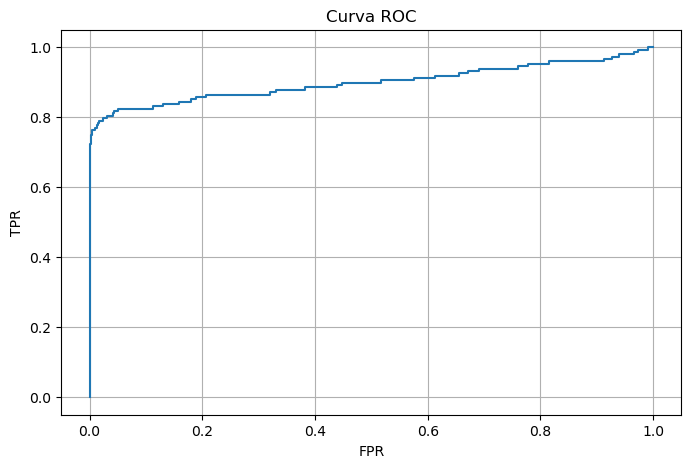

AUC: 0.8989188555458559


In [9]:
# 7️⃣ Curva ROC

fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.figure(figsize=(8,5))
plt.plot(fpr, tpr)
plt.title("Curva ROC")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.grid()
plt.show()

print("AUC:", roc_auc_score(y_test, y_probs))

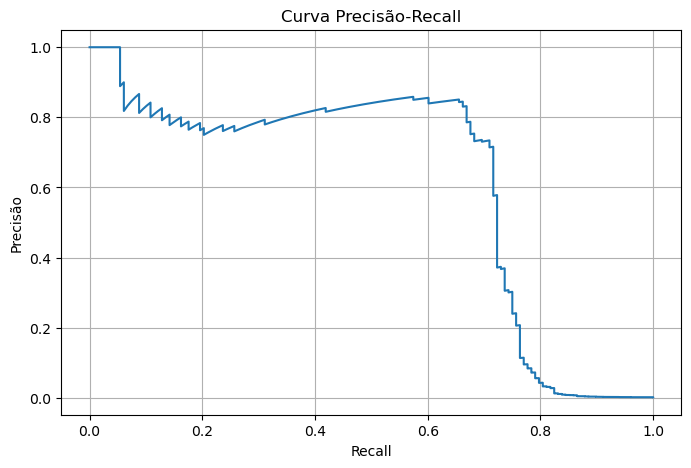

In [10]:
# 8️⃣ Curva Precisão-Recall

precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.figure(figsize=(8,5))
plt.plot(recall, precision)
plt.title("Curva Precisão-Recall")
plt.xlabel("Recall")
plt.ylabel("Precisão")
plt.grid()
plt.show()

In [11]:
# 9️⃣ Random Forest

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.76      0.79       148

    accuracy                           1.00     85443
   macro avg       0.92      0.88      0.90     85443
weighted avg       1.00      1.00      1.00     85443



In [12]:
# 🔟 XGBoost

peso = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb = XGBClassifier(
    scale_pos_weight=peso,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

print(classification_report(y_test, pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.88      0.79      0.83       148

    accuracy                           1.00     85443
   macro avg       0.94      0.90      0.92     85443
weighted avg       1.00      1.00      1.00     85443



In [13]:
# 1️⃣1️⃣ Grid Search

param_grid = {
    "max_depth": [3, 5],
    "n_estimators": [50, 100]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss"),
    param_grid,
    scoring="recall",
    cv=3
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 3, 'n_estimators': 100}


In [18]:
# 1️⃣2️⃣ SHAP

explainer = shap.TreeExplainer(xgb)

sample = X_test.iloc[:200]

shap_values = explainer(sample)

shap.summary_plot(shap_values, sample)

ValueError: could not convert string to float: '[5E-1]'